<a href="https://colab.research.google.com/github/ichristov/intermediate-fluid-mechanics/blob/main/Slipper_Pad_Bearing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LEARNING OBJECTIVE

This notebook shows how to understand Poiseuille&ndash;Couette (PC) flow underneath a slipper pad bearing using lubrication theory. This notebook builds on the previous demonstration of unidirectional PC flow in a straight channel. The velocity profile and the nonlinear pressure distribution generated by the lubrication flow are visualized.

# PRELIMINARIES

[run the next cell to setup Python environment customizations and load packages]

In [ ]:
# interactive plots setup
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets

# sympy setup
import sympy as sp
sp.init_printing()
from sympy.vector import *
from IPython.display import display, Math

# ploting customizations
from matplotlib import pyplot as plt
import matplotlib.patches as patches
size=16
params = {'legend.fontsize': 'large',
#          'figure.figsize': (20,8),
          'axes.labelsize': size,
          'axes.titlesize': size,
          'xtick.labelsize': size*0.875,
          'ytick.labelsize': size*0.875,
          'axes.titlepad': 25}
plt.rcParams.update(params)
%matplotlib inline

# numerics
import numpy as np

# for Colab only: to save plots as files and download them
#from google.colab import files

## Credit

Initial version written by [Ivan C. Christov](http://christov.tmnt-lab.org), Purdue University.

# FLOW GENERATED UNDER A MOVING SLIPPER PAD

A 2D slipper pad with rigid, non-straight side extends infinitely out of the page. The characteristic height of the fluid layer under the slipper pad is $h_0$, the height of the fluid layer at the entry point under the pad. The distance between the lower rigid wall and the slipper pad bottom side is $h(x) = h_0 h^*(x^*)$, $x^*=x/L$, where $h^*(x^*)$ will be specified below. The axial length of the slipper pad is $L$. The pressure before and beyond the slipper pad is uniform and equal to $p_0$.

## Governing equations

The dimensional lubrication equations are
\begin{alignat*}{3}
    \text{[COM]}\qquad &&\frac{\partial v_x}{\partial x} + \frac{\partial v_y}{\partial y} &= 0,\\
    \text{[COLM-$x$]}\qquad &&0 &\approx -\frac{\partial p}{\partial x} + \mu \frac{\partial^2 v_x}{\partial y^2},\\
    \text{[COLM-$y$]}\qquad &&0 &\approx -\frac{\partial p}{\partial y}.
\end{alignat*}
The boundary conditions (no slip, no penetration, uniform pressure outside the slipper pad) are
\begin{align*}
    v_x(x,y=0) &= 0,\\
    v_y(x,y=0) &= 0.\\
    v_x\big(x,y=h(x)\big) &= V_{x} = \text{const.},\\
    v_y\big(x,y=h(x)\big) &= V_{y} = \text{const.},\\
    p(x=0,y) &= p_0,\\
    p(x=L,y) &= p_0.
\end{align*}

## The horizontal velocity

The solution of COLM-$y$ subject to these boundary conditions is once again the combined Poiseuille&ndash;Couette flow, but with $h=h(x)$:
$$
    v_x(x,y) = V_{x} \frac{y}{h(x)} + \frac{[h(x)]^2}{2\mu}\left(-\frac{\partial p}{\partial x}\right) \left\{ \frac{y}{h(x)} - \left[\frac{y}{h(x)}\right]^2 \right\},
$$
where the pressure $p(x)$ is currently unknown. We'll keep using partial derivatives for clarity, but most quantities are only functions of $x$.

## The vertical velocity

From COM, we have
\begin{align*}
    v_y(x,y) &= - \int_0^y \frac{\partial v_x}{\partial x} d\tilde{y} \\
           &= \frac{V_{x}}{2} \left[\frac{y}{h(x)}\right]^2 \frac{\partial h}{\partial x}
           - \frac{1}{2\mu} \left(-\frac{\partial^2 p}{\partial x^2}\right)\left[h(x) \frac{y^2}{2} - \frac{y^3}{3} \right]
           - \frac{1}{4\mu} \left(-\frac{\partial p}{\partial x}\right) \frac{\partial h}{\partial x} y^2 
\end{align*}

## The pressure

Repeating the step for finding $v$, but integrating all the way to $y=h(x)$ and using the boundary condition, we get
\begin{align*}
    V_{y} &= - \int_0^{h(x)} \frac{\partial v_x}{\partial x} \,dy \\
      &\overbrace{=}^{\text{Leibniz}} - \frac{\partial }{\partial x} \int_0^{h(x)} v_x(x,y) \,dy + \underbrace{v_x\big(x,y=h(x)\big)}_{V_{x}}\frac{\partial h}{\partial x} \\
      &= - \frac{\partial }{\partial x} \left\{ V_{x} \frac{h(x)}{2} - \frac{[h(x)]^3}{12\mu} \frac{\partial p}{\partial x} \right\} + V_{x} \frac{\partial h}{\partial x} \\
      &= \frac{\partial }{\partial x} \left\{ \frac{[h(x)]^3}{12\mu} \frac{\partial p}{\partial x} \right\} + \frac{V_{x}}{2} \frac{\partial h}{\partial x}.
\end{align*}

We do not eliminate $V_{y}$ from the equations using the kinematic BC, since we want to impose this value to make plots below.

The last equation can be integrated to find the pressure:
$$
    V_{y} \, x - \frac{V_{x}}{2} h(x) = \frac{[h(x)]^3}{12\mu}\frac{\partial p}{\partial x} + C_1,
$$
or
$$
    \frac{12\mu}{[h(x)]^3} \left[ V_{y} \, x - \frac{V_{x}}{2} h(x) - C_1 \right] = \frac{\partial p}{\partial x},
$$
or
$$
    p(x) = \int_0^x \frac{12\mu}{[h(x)]^3} \left[ V_{y} \, x - \frac{V_{x}}{2} h(x) - C_1 \right] dx + p_0.
$$
Note that $C_1$ is truly a _constant_, not a function, of integration, since $\partial p/\partial y=0$ and $h=h(x)$ only.

### Making it dimensionless

Let's make the result dimensionless:
$$
    p^*(x^*) = \frac{p(x) - p_0}{\mu V_{x} L/h_0^2} = 12\int_0^{x^*} \frac{1}{[h^*(x^*)]^3} \left[  \frac{V_{y} L}{h_0 V_{x}} x^* - \frac{1}{2}h^*(x^*) - C_1^* \right] dx^*.
$$
Here, $x^* = x/L$ and $h^*(x^*) = h(x)/h_0$, and ${V_{y} L}/{h_0 V_{x}} = V^*$ is a dimensionless parameter we can vary. 

The pressure is subject to the final boundary condition $p^*(1) = 0$, thus
$$
    C_1^* = \frac{\int_0^1 \frac{1}{[h^*(x^*)]^3} \left[ V^* x^* - \frac{1}{2} h^*(x^*) \right] dx^*}{\int_0^1 \frac{1}{[h^*(x^*)]^3} dx^*}.
$$

# PRESSURE FOR GIVEN GAP SHAPE

In [2]:
xs, xsm, xt, ys, C1s, Vs, alpha = sp.symbols('x^*, x_m^*, xtilde, y^*, C_1^*, V^*, alpha')

hs = 1 + alpha*xs
hs

Starting with the given $h^*(x^*)$ and the formulas above, evaluate $C_1^*$:

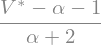

In [3]:
C1s = sp.integrate((Vs*xs-hs/2)/hs**3,(xs,0,1))/sp.integrate(1/hs**3,(xs,0,1))
C1s.simplify()

and $p^*(x^*)$:

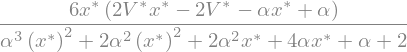

In [4]:
# need to introduce dummy variable xtilde for integration
ps = 12*sp.integrate(((Vs*xs-hs/2-C1s)/hs**3).subs(xs,xt),(xt,0,xs)).simplify()
ps

The pressure reaches an extremum (maximum or minimum) value at $x^*=x^*_m$ such that $(d p^*/d x^*)|_{x^*=x_m}=0$. We compute it to find that it only depends on $\alpha$:

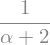

In [6]:
xsm = sp.solve(sp.Eq(ps.diff(xs),0),xs)[0]
xsm

And the extremum pressure value $p^*_m = p^*(x^*_m)$ depends on _both_ $\alpha$ and $V^*$:

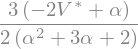

In [7]:
ps.subs(xs,xsm).simplify()

The case of $\alpha=0$ has to be evaluated as a limit because otherwise we will get a division by zero error somewhere. 

In [8]:
ps0 = sp.limit(ps,alpha,0)
ps0.simplify()

Also, we define the velocity components symbolically from our formulas above; the expressions are a bit ugly.

In [9]:
vxs = (ys/hs) + (1/2)*(hs**2)*(-ps.diff(xs))*(ys/hs - (ys/hs)**2)
vys = (1/2)*((ys/hs)**2)*hs.diff(xs) - (1/2)*(-ps.diff(xs,2))*(hs*(ys**2)/2-(ys**3)/3) \
      - (1/2)*(-ps.diff(xs))*hs.diff(xs)*(ys**2)/2

Next, we check our work symbolically with SymPy.

In [19]:
# check BCs on symbolic expressions
# got a little fancy here with display Math here ...
display(Math(r'\text{checking}~~~~p^*~\text{at}~x^*=0~~~~~:~'+
                sp.latex(ps.subs(xs,0))))
display(Math(r'\text{checking}~~~~p^*~\text{at}~x^*=1~~~~~:~'+
                sp.latex(ps.subs(xs,1))))
display(Math(r'\text{checking}~~~~v_x^*~\text{at}~y^*=0~~~~~:~'+ 
             sp.latex(vxs.subs(ys,0))))
display(Math(r'\text{checking}~~~~v_x^*~\text{at}~y^*=h^*~~~:~'+ 
             sp.latex(vxs.subs(ys,hs))))
display(Math(r'\text{checking}~~~~v_y^*~\text{at}~y^*=0~~~~~:~'+ 
             sp.latex(vys.subs(ys,0))))
display(Math(r'\text{checking}~~~~v_y^*~\text{at}~y^*=h^*~~~:~'+ 
             sp.latex(vys.subs(ys,hs).simplify())))
# check COM with symbolic expressions
display(Math(r'\text{checking}~~~~\frac{\partial v_x^*}{\partial x^*}+\frac{\partial v_y^*}{\partial y^*}~~~~~~:~'+ 
             sp.latex((vxs.diff(xs) + vys.diff(ys)).simplify())))
# check COLM with symbolic expressions
display(Math(r'\text{checking}~~~~-\frac{\partial p^*}{\partial x^*}+\frac{\partial^2 v_x^*}{\partial y^{*2}}:~'+ 
             sp.latex((-ps.diff(xs) + vxs.diff(ys,2)).simplify())))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Finally, we [`lambdify`](https://docs.sympy.org/latest/modules/utilities/lambdify.html) our functions for evaluation and plotting.

In [12]:
lam_h = sp.lambdify([xs, alpha], hs)

lam_p = sp.lambdify([xs, Vs, alpha], ps)
lam_p0 = sp.lambdify([xs, Vs], ps0)

lam_vx = sp.lambdify([xs, ys, Vs, alpha], vxs)
lam_vy = sp.lambdify([xs, ys, Vs, alpha], vys)

# VISUALIZATION

In [13]:
def plot_func(Vs,α):
  # x^* goes from 0 to 1
  xp = np.linspace(0, 1, num=100)

  fig, ax = plt.subplots(tight_layout=True)

  ax.set_ylabel('$h^*(x^*) = h(x)/h_0$')
  ax.set_ylim(-3,2)
  ax.set_xlabel('$x^* = x/L$')
  ax.set_xlim(0,1)
  ax.plot(xp,lam_h(xp,α),color='gray',linestyle='dashed')

  ax2 = ax.twinx()
  ax2.set_ylabel(r'$p^*(x^*) = \frac{p(x) - p_0}{\mu V_{x,0} L/h_0^2}$')
  ax2.set_ylim(-5,5) # might have to be judicious

  ax2.plot(xp,0*xp, linestyle='dotted', linewidth=0.5, color='black')
  # handle α = 0 case separately as a limit
  if α != 0:
    ax2.plot(xp,lam_p(xp,Vs,α))
  else:
    ax2.plot(xp,lam_p0(xp,Vs))
    
  # show a grid to make it easier to see where the y=0 interface is
  ax.grid(alpha=0.5, linestyle='dotted')

  plt.show()

First, a static plot.

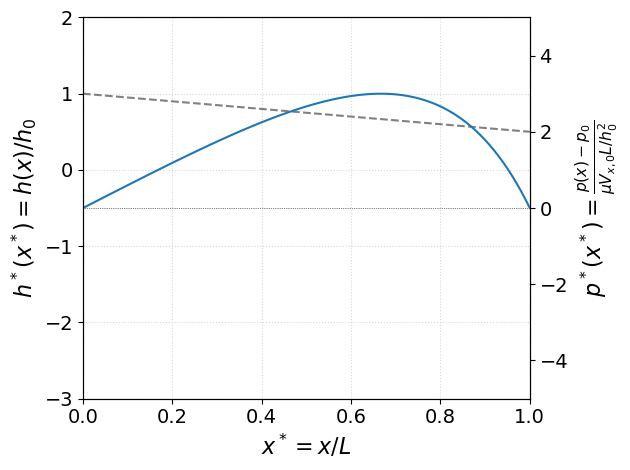

In [14]:
plot_func(-1.0,-0.5)

Next, an [`interact`](https://ipywidgets.readthedocs.io/en/latest/examples/Using%20Interact.html) widget will let us vary $\alpha$ and $V^*$.

In [ ]:
interact(plot_func, Vs = widgets.FloatSlider(value=-1,
                                             min=-2,
                                             max=+2,
                                             step=0.1,
                                             description='V*'),
                    α = widgets.FloatSlider(value=-0.5,
                                             min=-0.999,
                                             max=1,
                                             step=0.02));

interactive(children=(FloatSlider(value=-1.0, description='V*', max=2.0, min=-2.0), FloatSlider(value=-0.5, de…

Finally, let's check out the velocity vector ([`quiver`](https://matplotlib.org/stable/gallery/images_contours_and_fields/quiver_simple_demo.html)) plot under the slipper pad.

In [18]:
def plot_func_vel(Vs,α):
  xp, yp = np.meshgrid( np.linspace(0.1, 0.8, num=5),
                        np.linspace(0, 2, num=25) )
  qs = 4 # scaling factor for quiver plot

  # y^* goes from 0 to h^* but we'll mask the values > h^* later
  mask = yp > lam_h(xp,α)

  vx = np.ma.masked_array(lam_vx(xp,yp,Vs,α), mask)
  vy = np.ma.masked_array(lam_vy(xp,yp,Vs,α), mask)

  fig, ax = plt.subplots(tight_layout=True)

  ax.set_ylabel('$y^* = y/h_0$')
  ax.set_ylim(0,2)
  ax.set_xlabel('$x^* = x/L$')
  ax.set_xlim(0,1)
  
  ax.quiver(xp, yp, vx, vy, 
            scale=qs, scale_units='xy', color='skyblue', zorder=2)

  # show the slipper pad
  vertices = [(0, 1), (0, 2), (1, 2), (1, lam_h(1,α))]
  polygon = patches.Polygon(vertices, closed=True, fill=False, hatch='///')
  ax.add_patch(polygon)

  # show a grid to make it easier to see where the y=0 interface is
  ax.grid(alpha=0.5, linestyle='dotted')

  plt.show()

First, a static plot.

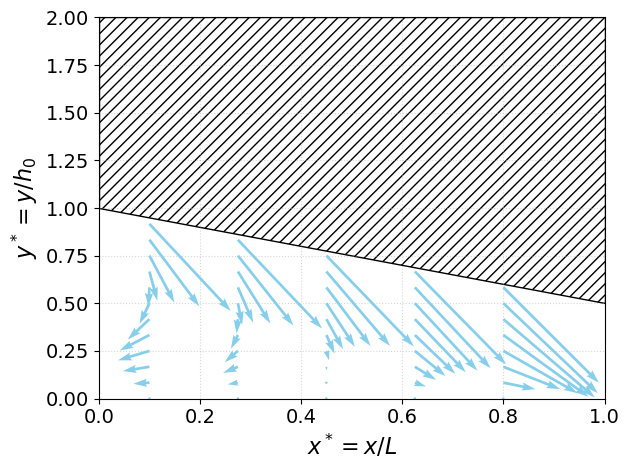

In [19]:
plot_func_vel(-1.0,-0.5)

Next, an [`interact`](https://ipywidgets.readthedocs.io/en/latest/examples/Using%20Interact.html) widget will let us vary $V^*$ and $\alpha$.

In [ ]:
interact(plot_func_vel, Vs = widgets.FloatSlider(value=-1,
                                                 min=-2,
                                                 max=+2,
                                                 step=0.1,
                                                 description='V*'),
                        α = widgets.FloatSlider(value=-0.5,
                                                min=-0.999,
                                                max=1,
                                                step=0.02));

interactive(children=(FloatSlider(value=-1.0, description='V*', max=2.0, min=-2.0), FloatSlider(value=-0.5, de…

# FURTHER EXPLORATION

On your own:

*   Try different $h^*(x^*)$ shapes, such as
    -   $h^*(x^*) = e^{\alpha x^*}$.
    -   $h^*(x^*) = \begin{cases} 1, &0\le x^* \le 1/2,\\ \alpha, &1/2 < x^* \le 1.\end{cases}$
*   Calculate the lubrication force $\int_0^L p(x) - p_0 \, dx$.
    -   Make it dimensionless.
    -   How does it vary with $V^*$ and $\alpha$?